# Import libraries

In [57]:
import os
from re import search
import scvelo as scv

In [58]:
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"

# Load settings

In [59]:
# exec(open('/bi/group/reik/ricard/scripts/gastrulation_multiome_10x/settings.py').read())
# exec(open('/bi/group/reik/ricard/scripts/gastrulation_multiome_10x/utils.py').read())

In [60]:
exec(open('/Users/argelagr/gastrulation_multiome_10x/settings.py').read())
exec(open('/Users/argelagr/gastrulation_multiome_10x/utils.py').read())


## Define I/O

In [61]:
io["anndata_scvelo"] = io["basedir"] + "/processed/rna/velocyto/anndata_scvelo.h5ad"
io["outdir"] = io["basedir"] + "results/rna/velocyto/cells"

## Define options 

scanpy options

In [133]:
# %%capture
# sc.settings.verbosity = 3
# sc.logging.print_versions()
sc.settings.set_figure_params(dpi=80, frameon=False, figsize=(8, 7), facecolor='white')
sc.settings.figdir = io["outdir"]

In [134]:
scv.set_figure_params('scvelo')  # for beautified visualization

In [63]:
opts["samples"] = [
#	"E8.0_rep1",
#	"E8.0_rep2",
#	"E8.5_rep1",
#	"E8.5_rep2",
	"E8.5_CRISPR_T_KO",
	"E8.5_CRISPR_T_WT"
]

opts["celltypes"] = [
  "Caudal_Mesoderm",
  "Somitic_mesoderm",
  "NMP",
  "Spinal_cord"
]

## Load cell metadata

In [64]:
metadata = (pd.read_table(io["metadata"]) >>
    mask(X.pass_rnaQC==True, X.doublet_call==False) >>
    mask(X["sample"].isin(opts["samples"]), X["celltype"].isin(opts["celltypes"]))
)
metadata.shape

(2402, 23)

In [65]:
metadata["sample"].value_counts()

E8.5_CRISPR_T_WT    1216
E8.5_CRISPR_T_KO    1186
Name: sample, dtype: int64

In [66]:
metadata["celltype"].value_counts()

NMP                 1071
Spinal_cord          962
Somitic_mesoderm     367
Caudal_Mesoderm        2
Name: celltype, dtype: int64

# Load anndata object

In [68]:
adata = load_adata(
    adata_file = io["anndata_scvelo"], 
    cells = metadata.cell.values, 
    metadata_file = io["metadata"],
    normalise = True, 
    filter_lowly_expressed_genes = False,
    set_colors = True
)
adata

1.37% of cells provided are not observed in the adata, taking the intersect...


AnnData object with n_obs × n_vars = 2369 × 2000
    obs: 'cell', 'barcode', 'sample', 'nFeature_RNA', 'nCount_RNA', 'mitochondrial_percent_RNA', 'ribosomal_percent_RNA', 'stage', 'genotype', 'pass_rnaQC', 'doublet_score', 'doublet_call', 'celltype', 'celltype.score', 'closest.cell', 'TSSEnrichment_atac', 'ReadsInTSS_atac', 'PromoterRatio_atac', 'NucleosomeRatio_atac', 'nFrags_atac', 'BlacklistRatio_atac', 'pass_atacQC', 'celltype.predicted'
    var: 'gene', 'Accession', 'Chromosome', 'End', 'Start', 'Strand', 'means', 'dispersions', 'dispersions_norm', 'highly_variable', 'fit_r2', 'fit_alpha', 'fit_beta', 'fit_gamma', 'fit_t_', 'fit_scaling', 'fit_std_u', 'fit_std_s', 'fit_likelihood', 'fit_u0', 'fit_s0', 'fit_pval_steady', 'fit_steady_u', 'fit_steady_s', 'fit_variance', 'fit_alignment_scaling', 'velocity_genes'
    uns: 'neighbors', 'pca', 'recover_dynamics', 'velocity_params', 'log1p', 'celltype_colors', 'stage_colors'
    obsm: 'X_pca'
    varm: 'PCs', 'loss'
    layers: 'Ms', 'Mu'

In [151]:
adata.obs["genotype"].value_counts()

WT      1203
T_KO    1166
Name: genotype, dtype: int64

## Feature selection

In [70]:
# sc.pp.highly_variable_genes(adata, layer=None, n_top_genes=2500)

# Dimensionality reduction

## PCA

Run PCA

In [71]:
# sc.tl.pca(adata, n_comps=25, svd_solver='arpack')

Plot PCA

In [72]:
# sc.pl.pca(adata, components=[1,2], color=["celltype.mapped","stage"], size=25, legend_loc=None)

## Batch effect correction

In [73]:
# sc.external.pp.harmony_integrate(adata, "stage", basis='X_pca', adjusted_basis='X_pca_harmony')

## k-NN graph

Build kNN graph

In [74]:
sc.pp.neighbors(adata, n_neighbors=15, n_pcs=25)

### Force-directed layout

In [75]:
sc.tl.draw_graph(adata, layout='fa', init_pos=None)

... storing 'barcode' as categorical
... storing 'sample' as categorical
... storing 'stage' as categorical
... storing 'genotype' as categorical
... storing 'celltype' as categorical
... storing 'closest.cell' as categorical
... storing 'celltype.predicted' as categorical


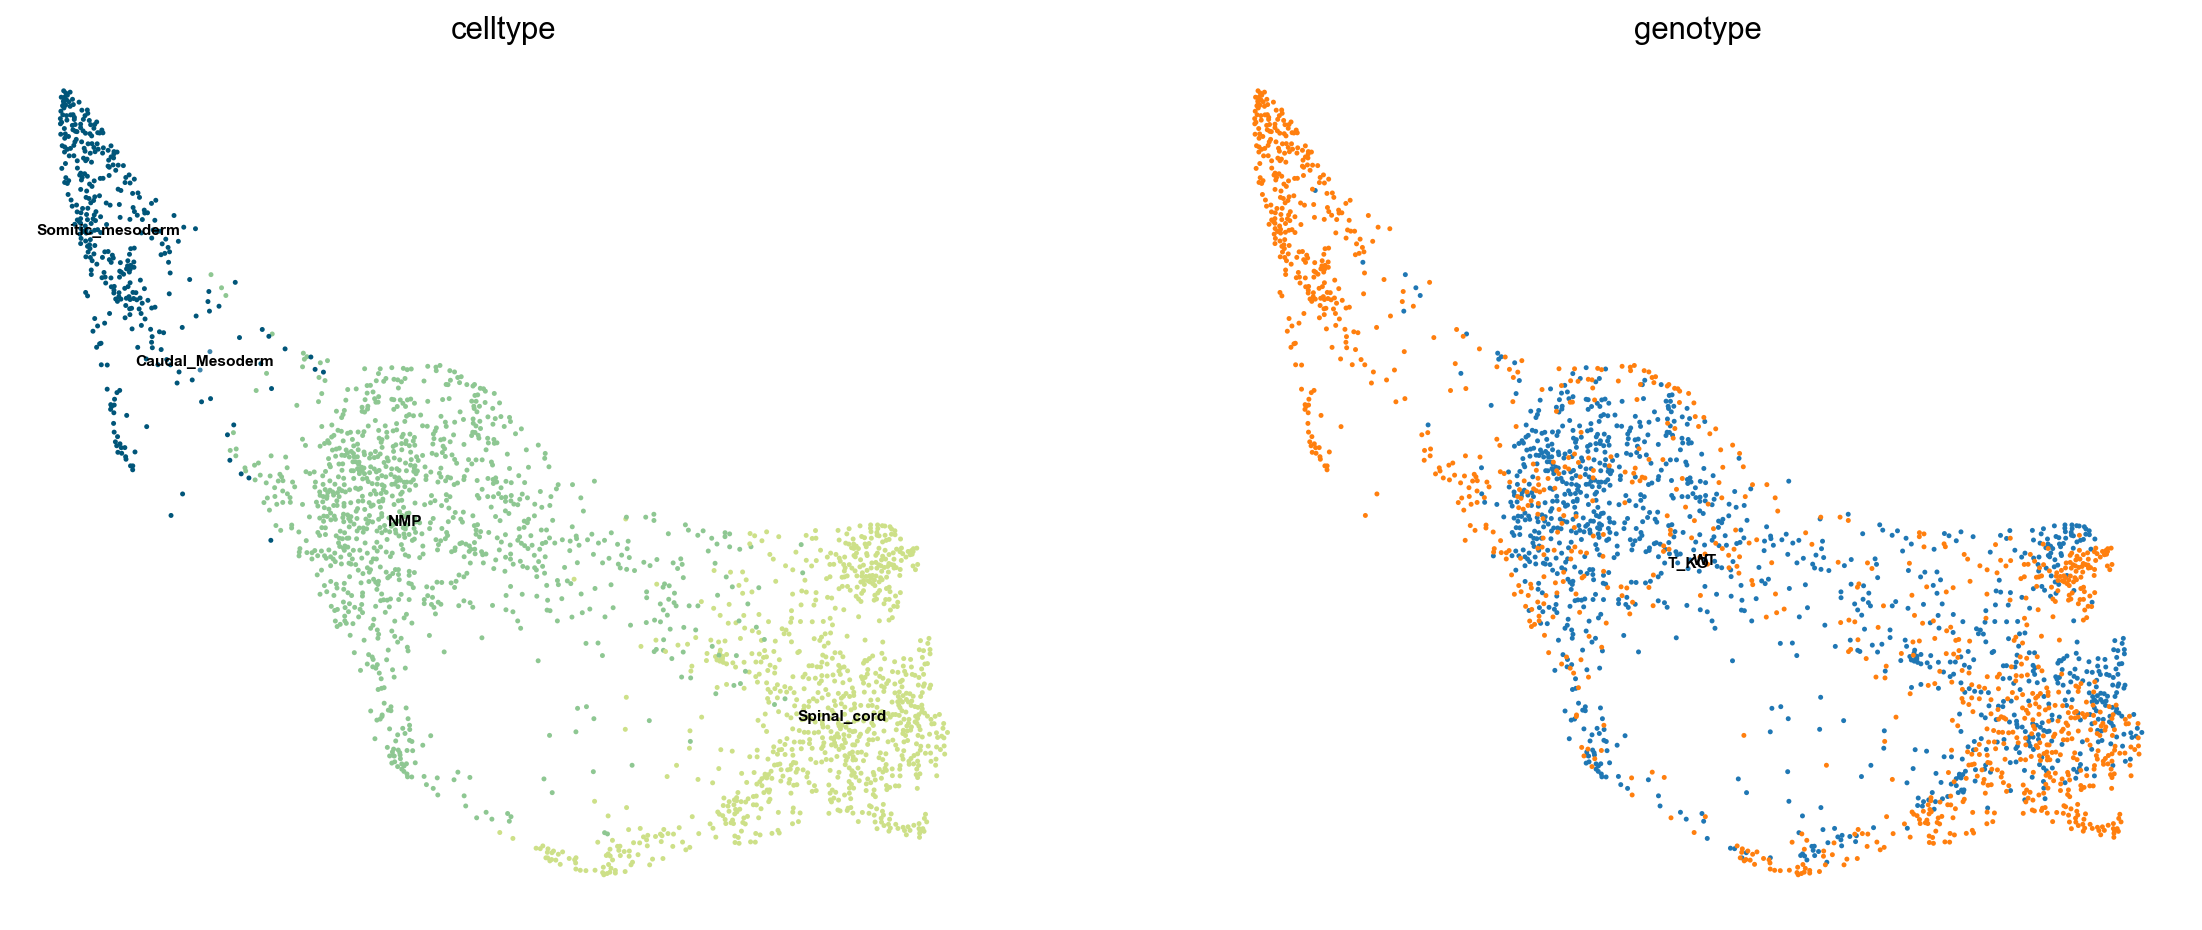

In [76]:
# sc.pl.draw_graph(adata, color='celltype', legend_loc='on data')
sc.pl.draw_graph(adata, color=["celltype","genotype"], size=20, legend_loc='on data', legend_fontsize=7)

In [78]:
# sc.pl.draw_graph(adata, color=["stage"], size=20, legend_loc='on data', legend_fontsize=12)

## UMAP

Run UMAP

In [54]:
# sc.tl.umap(adata, min_dist=0.5, n_components=2)

Plot UMAP

In [ ]:
# sc.pl.umap(adata, color=["celltype.mapped","stage"], size=25, legend_loc="on data")
# sc.pl.umap(adata, color=["celltype.mapped","genotype"], size=50, legend_loc=None)

## Downstream analysis

Computes velocity graph based on cosine similarities.

In [79]:
#scv.tl.velocity_graph(adata)
scv.tl.velocity_graph(adata, approx=True) 

computing velocity graph
    finished (0:00:00) --> added 
    'velocity_graph', sparse matrix with cosine correlations (adata.uns)


scvelo.pl.velocity_embedding_grid(adata, basis=None, vkey='velocity', density=None, smooth=None, min_mass=None, arrow_size=None, arrow_length=None, arrow_color=None, scale=None, autoscale=True, n_neighbors=None, recompute=None, X=None, V=None, X_grid=None, V_grid=None, principal_curve=False, color=None, use_raw=None, layer=None, color_map=None, colorbar=True, palette=None, size=None, alpha=0.2, perc=None, sort_order=True, groups=None, components=None, projection='2d', legend_loc='none', legend_fontsize=None, legend_fontweight=None, xlabel=None, ylabel=None, title=None, fontsize=None, figsize=None, dpi=None, frameon=None, show=None, save=None, ax=None, ncols=None, **kwargs)

In [115]:
for i in ["velocity"]:
    adata.layers[vkey] = adata.layers[vkey].todense()

saving figure to file ./figures/scvelo_fa_layout_velocity_wt.pdf


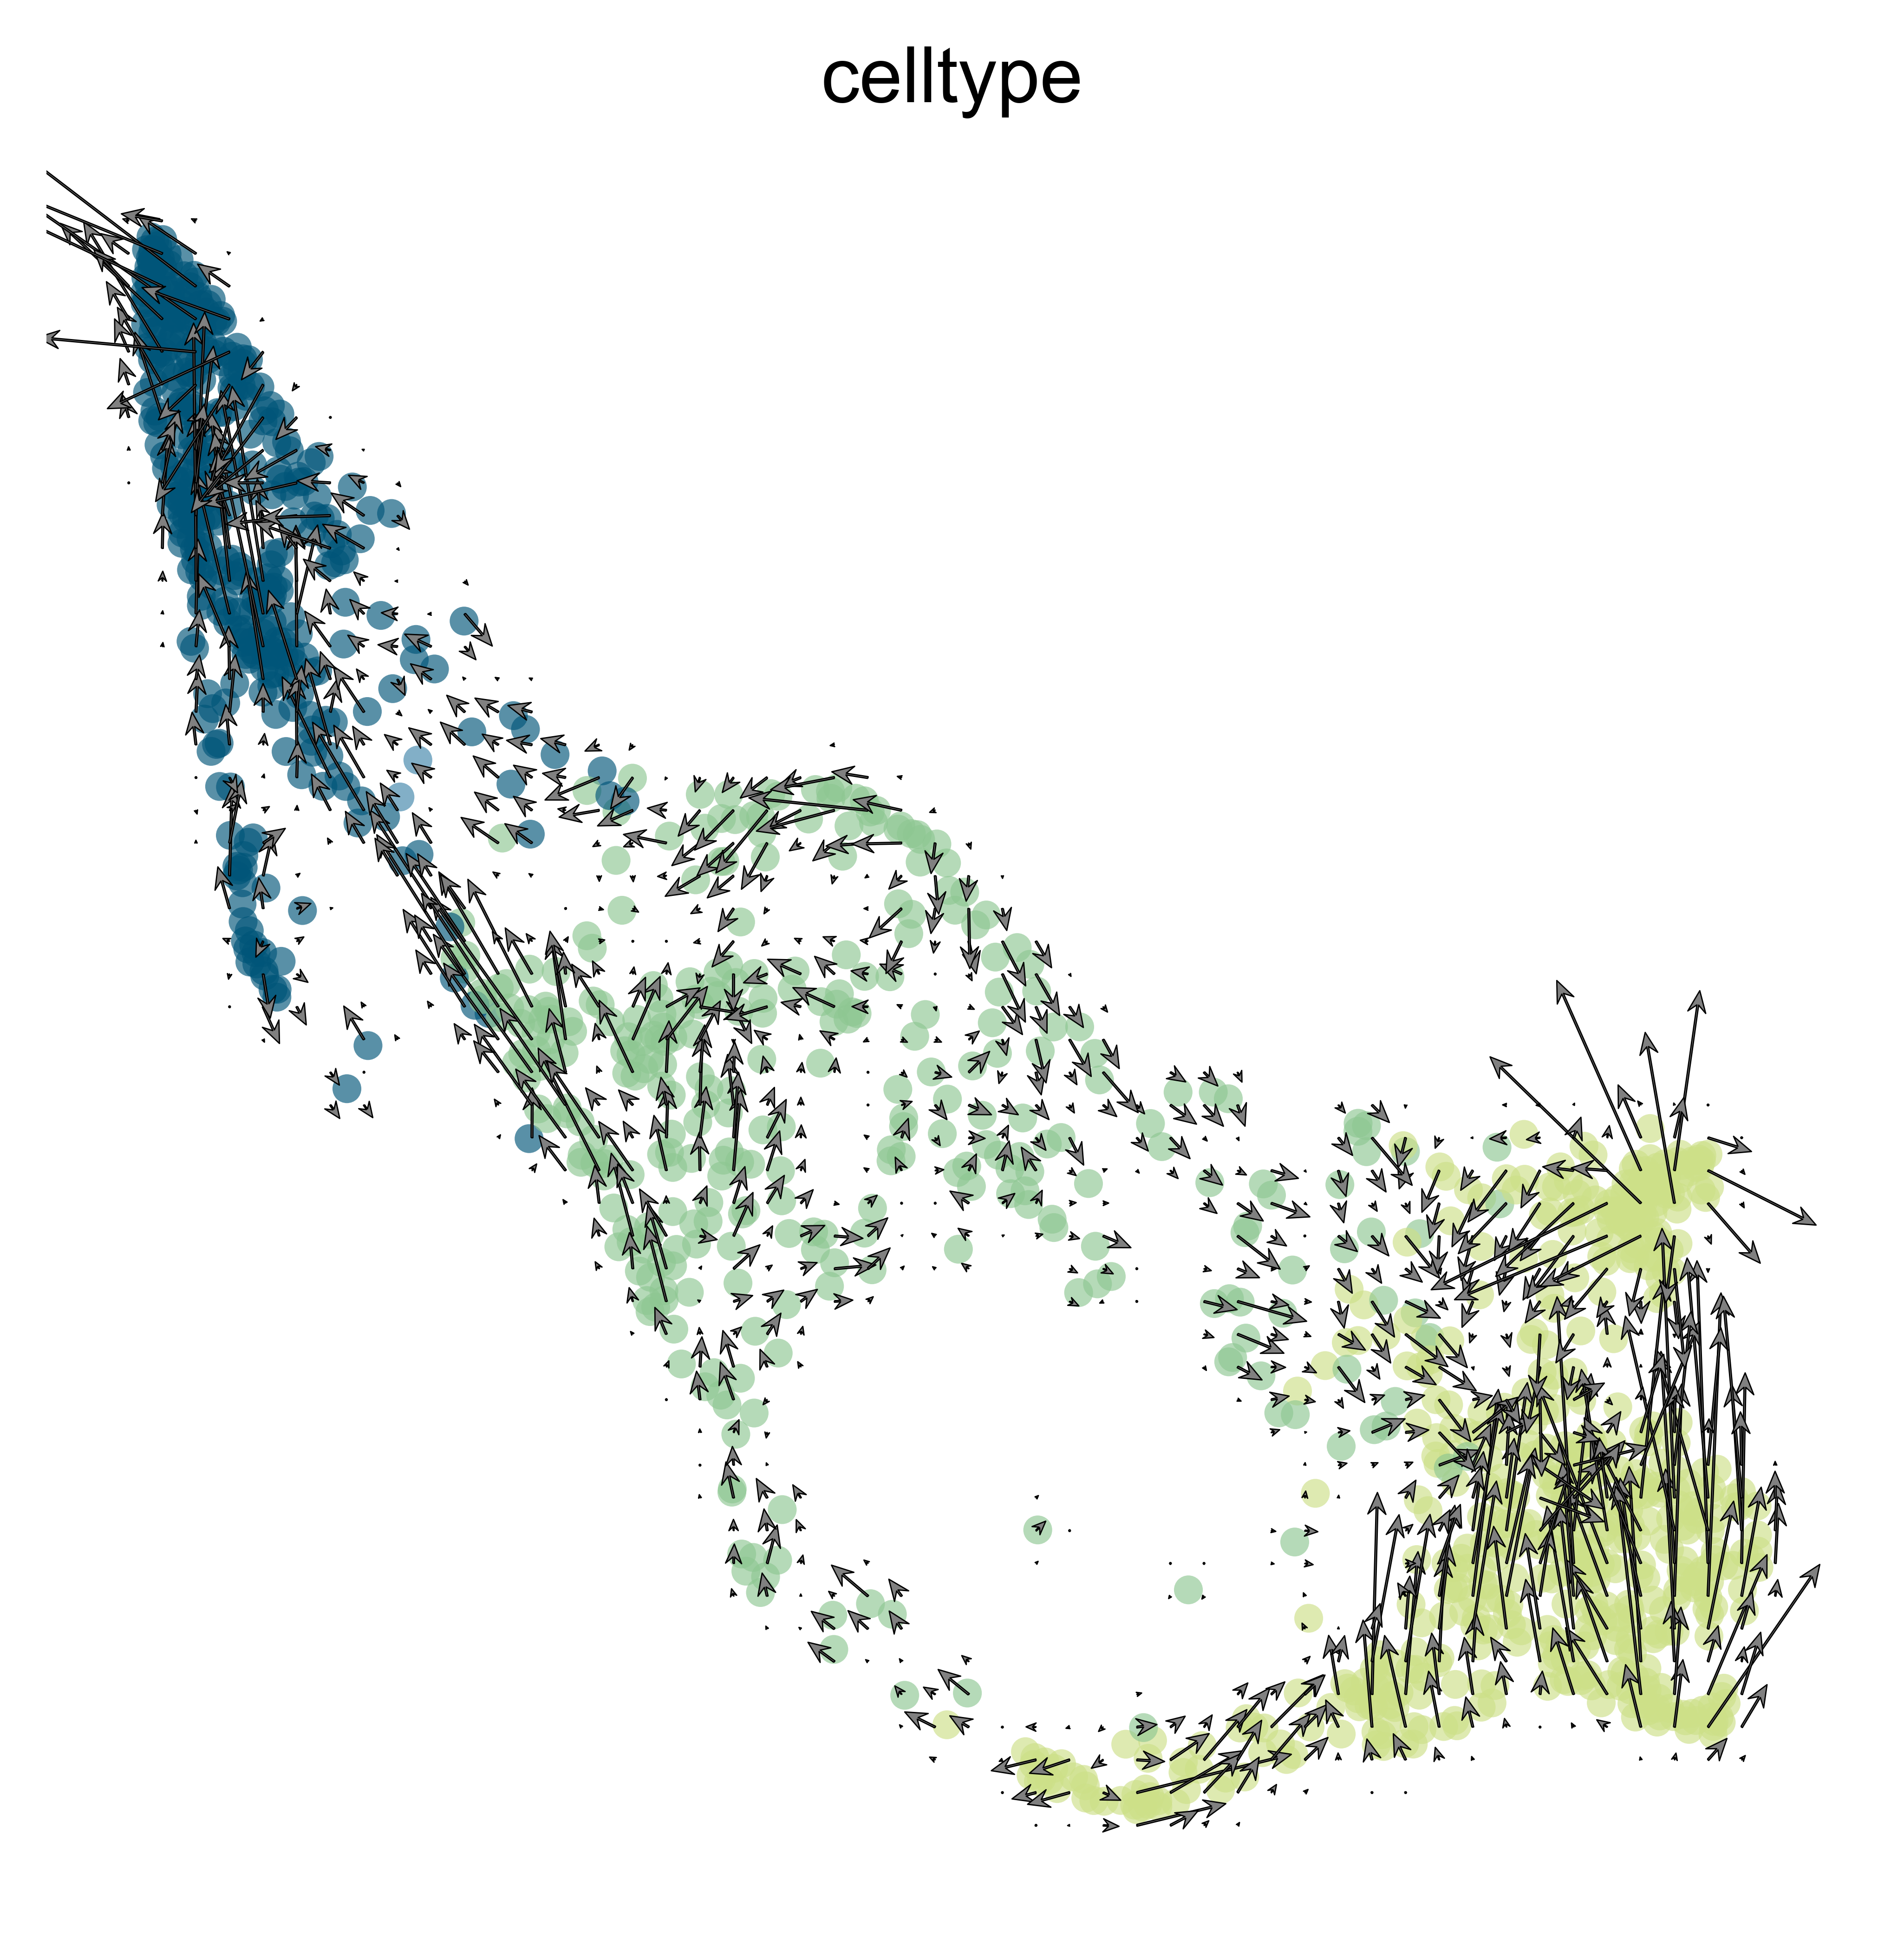

In [149]:
scv.pl.velocity_embedding_grid(
    adata[adata.obs["genotype"]=="WT",:], basis='X_draw_graph_fa', color=['celltype'], size=80, alpha=0.65, 
    arrow_length=5, arrow_size=2, dpi=500, legend_loc="none", save="fa_layout_velocity_wt.pdf", figsize=(5,5)
)

saving figure to file ./figures/scvelo_fa_layout_velocity_ko.pdf


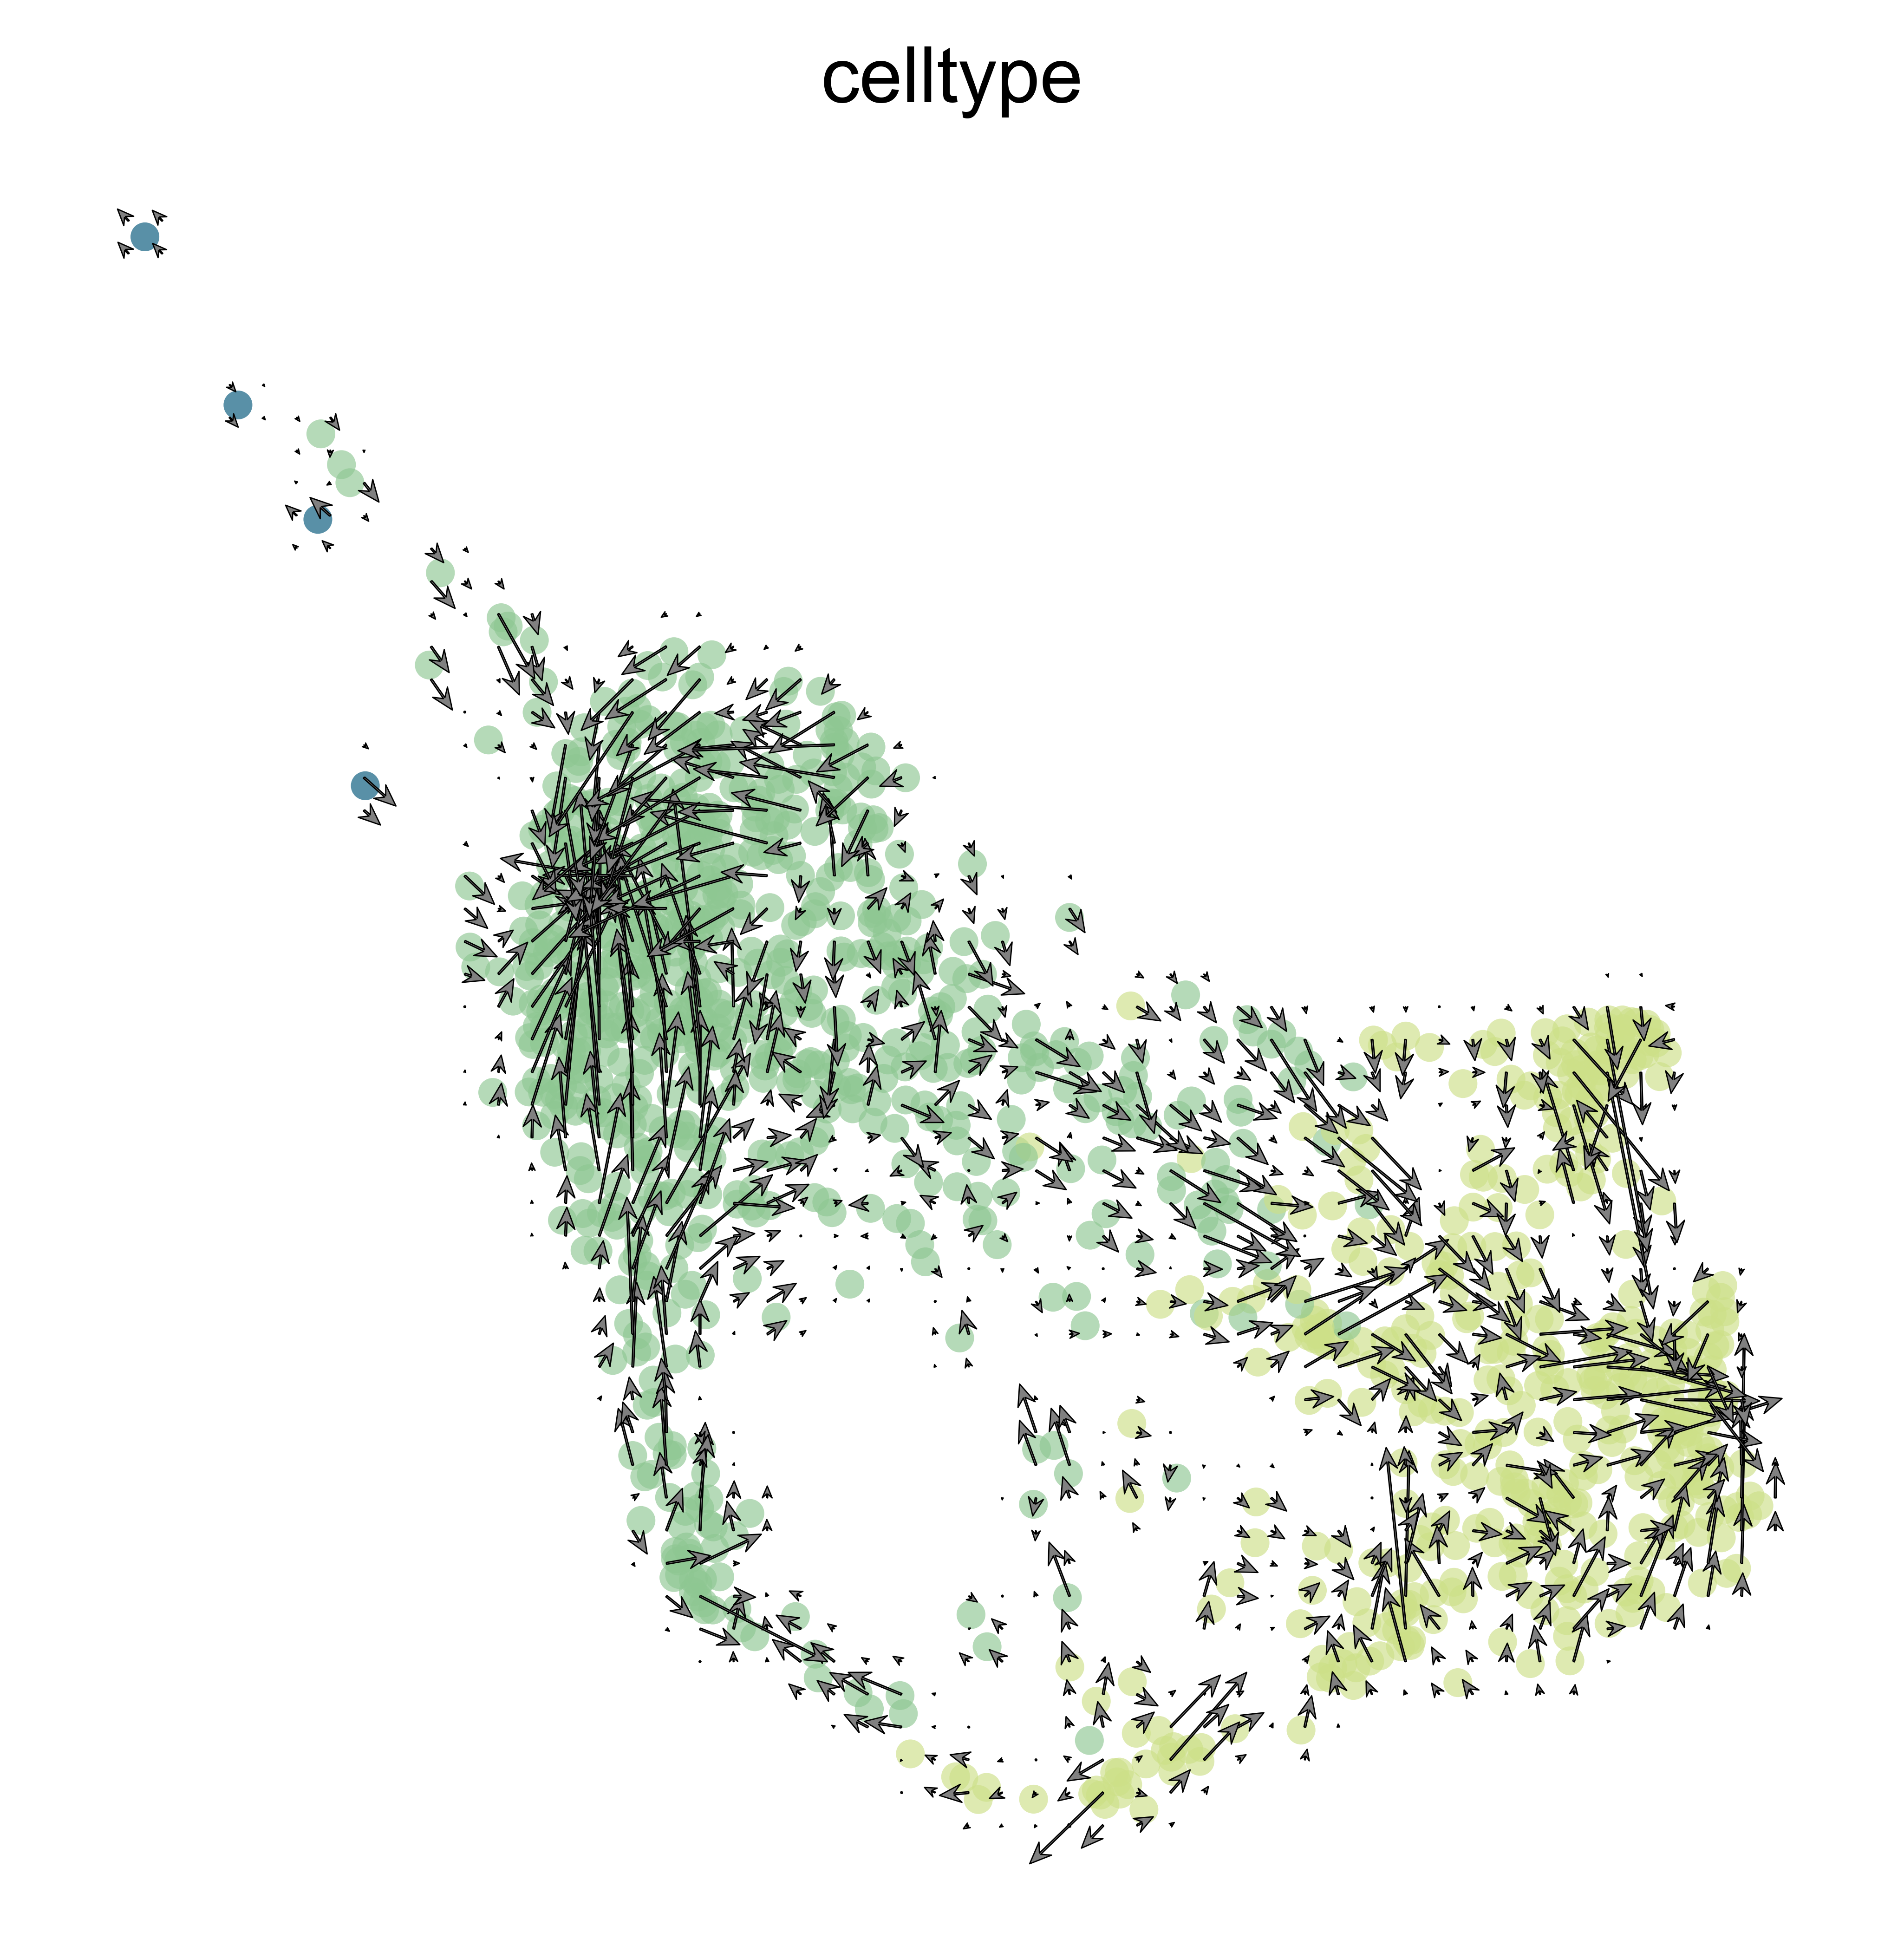

In [150]:
scv.pl.velocity_embedding_grid(
    adata[adata.obs["genotype"]=="T_KO",:], basis='X_draw_graph_fa', color=['celltype'], size=80, alpha=0.65, 
    arrow_length=5, arrow_size=2, dpi=500, legend_loc="none", save="fa_layout_velocity_ko.pdf", figsize=(5,5)
)

scvelo.pl.velocity_embedding_stream(adata, basis=None, vkey='velocity', density=None, smooth=None, min_mass=None, cutoff_perc=None, arrow_color=None, linewidth=None, n_neighbors=None, recompute=None, color=None, use_raw=None, layer=None, color_map=None, colorbar=True, palette=None, size=None, alpha=0.3, perc=None, X=None, V=None, X_grid=None, V_grid=None, sort_order=True, groups=None, components=None, legend_loc='on data', legend_fontsize=None, legend_fontweight=None, xlabel=None, ylabel=None, title=None, fontsize=None, figsize=None, dpi=None, frameon=None, show=None, save=None, ax=None, ncols=None, **kwargs)

In [96]:
scv.pl.velocity_embedding_stream(adata, basis='X_draw_graph_fa', color=['celltype',"genotype"], 
    legend_loc='right margin', linewidth=1, legend_fontsize=8, dpi=500)

computing velocity embedding


TypeError: ufunc 'isnan' not supported for the input types, and the inputs could not be safely coerced to any supported types according to the casting rule ''safe''

## Phase portraits 

## Latent time

Gene-specific latent timepoints obtained from the dynamical model are coupled to a universal gene-shared latent time, which represents the cell’s internal clock and is based only on its transcriptional dynamics.

scvelo.tl.latent_time(data, vkey='velocity', min_likelihood=0.1, min_confidence=0.75, min_corr_diffusion=None, weight_diffusion=None, root_key=None, end_key=None, t_max=None, copy=False)

In [ ]:
scv.tl.latent_time(adata)
scv.pl.scatter(adata, color='latent_time', color_map='gnuplot', size=80)

Now, let us examine the phase portraits of some marker genes, visualized with scv.pl.velocity(adata, gene_names) or scv.pl.scatter(adata, gene_names).

The black line corresponds to the estimated ‘steady-state’ ratio, i.e. the ratio of unspliced to spliced mRNA abundance which is in a constant transcriptional state. RNA velocity for a particular gene is determined as the residual, i.e. how much an observation deviates from that steady-state line. Positive velocity indicates that a gene is up-regulated, which occurs for cells that show higher abundance of unspliced mRNA for that gene than expected in steady state. Conversely, negative velocity indicates that a gene is down-regulated.

In [ ]:
# all_genes = adata.var.index
#genes_to_plot = all_genes[all_genes.str.match("^Hb-*")][0]
genes_to_plot = "Sox17"

scvelo.pl.velocity(adata, var_names=None, basis=None, vkey='velocity', mode=None, fits=None, layers='all', color=None, color_map=None, colorbar=True, perc=[2, 98], alpha=0.5, size=None, groupby=None, groups=None, legend_loc='none', legend_fontsize=8, use_raw=False, fontsize=None, figsize=None, dpi=None, show=None, save=None, ax=None, ncols=None, **kwargs)

In [ ]:
scv.pl.velocity(adata, genes_to_plot, size=15)

scvelo.pl.scatter(adata=None, basis=None, x=None, y=None, vkey=None, color=None, use_raw=None, layer=None, color_map=None, colorbar=None, palette=None, size=None, alpha=None, linewidth=None, linecolor=None, perc=None, groups=None, sort_order=True, components=None, projection=None, legend_loc=None, legend_loc_lines=None, legend_fontsize=None, legend_fontweight=None, legend_fontoutline=None, xlabel=None, ylabel=None, title=None, fontsize=None, figsize=None, xlim=None, ylim=None, add_density=None, add_assignments=None, add_linfit=None, add_polyfit=None, add_rug=None, add_text=None, add_text_pos=None, add_outline=None, outline_width=None, outline_color=None, n_convolve=None, smooth=None, rescale_color=None, color_gradients=None, dpi=None, frameon=None, zorder=None, ncols=None, nrows=None, wspace=None, hspace=None, show=None, save=None, ax=None, **kwargs)

In [ ]:
scv.pl.scatter(adata, genes_to_plot, size=35, color=['celltype.mapped', 'velocity'])

Driver genes display pronounced dynamic behavior and are systematically detected via their characterization by high likelihoods in the dynamic model.



In [ ]:
top_genes = adata.var['fit_likelihood'].sort_values(ascending=False).index
scv.pl.scatter(adata, basis=top_genes[:10], ncols=5, frameon=False)